# Experiment 1 – Value-based decisions (food snacks): GOAL model fit (Normal prior)

Fits the Goal-oriented Asymmetric Likelihood (GOAL) model separately to each goal frame.

- **Data:** `DataFoodFramingNotebook_31.csv`; frames `BlockCond == 1` (Like) and `BlockCond == 2` (Dislike) (evidence = subjective value (BDM willingness to pay) of the left/right item).
- **Model:** Normal priors on the belief SDs, N(5, 1) – main text (Figure 6). Means of the low/high belief distributions are fixed from a median split of the evidence; choice and confidence (with RT) are observed.
- **Fitting:** even-numbered trials, PyMC NUTS, 4 chains × 4000 draws (1000 tuning).
- **Output:** posterior traces saved as `.nc` files, used by `Figure_exp1-4_ModelFit_NormalPrior.ipynb` to simulate held-out trials and make the figures.

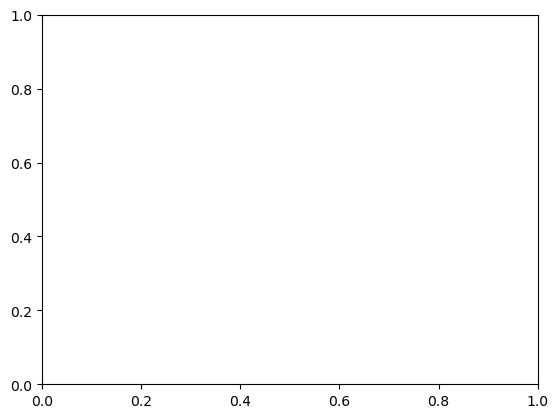

In [1]:
import pymc as pm
import pandas as pd
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import  pytensor.tensor as pt

import functionsSims as fs

In [2]:
def mainLoad(data_part_all0):
    # Prepare one frame: z-score within participant, split even/odd trials,
    # extract model inputs and plot the evidence/confidence distributions

    # z-score values
    data_part_all0['zLValue'] = fs.zscore1(data_part_all0,'LValue', 'Part')
    data_part_all0['zRValue'] = fs.zscore1(data_part_all0,'RValue', 'Part')
    data_part_all0['zConf'] = fs.zscore1(data_part_all0,'Conf', 'Part')
    data_part_all0['zRT'] = fs.zscore1(data_part_all0,'ChoiceRT', 'Part')

    # estimate choice and confidence compound
    data_part_all0['choiceConf'] = data_part_all0.Conf * (2*data_part_all0.ChosenITM-1) # second term is to transform choice to left : -1; right: +1
    data_part_all0['zChoiceConf'] = fs.zscore1(data_part_all0,'choiceConf', 'Part')

    # Split trials: model fitted to even trials, odd trials kept as test set
    data_part_all = data_part_all0.loc[data_part_all0.TrialN%2 == 0]
    data_part_all_test = data_part_all0.loc[data_part_all0.TrialN%2 == 1]

    # load input 
    val_a = data_part_all.zLValue.values
    val_b = data_part_all.zRValue.values
    chosenByPart = data_part_all.ChosenITM.values
    rtByPart = data_part_all.zRT.values

    # generate all values to be sorted to generate high and low value distributions
    value_sort = data_part_all.copy()
    value_sort = value_sort.zLValue.values

    confByPart = data_part_all.zConf.values
    choiceConfByPart = data_part_all.zChoiceConf.values

    confNormByPart = fs.norm01(data_part_all,'zConf','Part')

    delta_og = data_part_all.zLValue
    delta_og.hist()
    plt.title(r"Distribution of values from participant")
    print('mean of the value distribution: ' + str(val_a.mean()))
    print('std of the value distribution: ' + str(val_a.std()))
    plt.show()

    val_og = data_part_all.zLValue
    conf_og = data_part_all.zConf
    conf_og.hist()
    plt.title(r"Distribution of confidence from participant (zScored)")
    print('mean of the confidence distribution: ' + str(conf_og.mean()))
    print('std of the confidence distribution: ' + str(conf_og.std()))
    plt.show()

    choiceConf_og = data_part_all0['Conf'] 
    plt.hist(choiceConf_og)
    plt.title(r"Distribution of zscored confidence from participant")
    print('mean : ' + str(np.mean(choiceConf_og)))
    print('std  : ' + str(np.std(choiceConf_og)))
    plt.show()

    choiceConf_og = confNormByPart
    plt.hist(choiceConf_og)
    plt.title(r"Distribution of normalized 0-1 confidence from participant")
    print('mean : ' + str(np.mean(choiceConf_og)))
    print('std  : ' + str(np.std(choiceConf_og)))
    plt.show()

    # Means of the low/high evidence distributions from a median split of the evidence (Figure S2)
    lvalParam, hvalParam = fs.split_values_highLow (value_sort)

    return val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test   

# Dislike frame

In [6]:
data_all = pd.read_csv('../Data/Sepulveda2020/DataFoodFramingNotebook_31.csv') 

mean of the value distribution: -0.015966113464672815
std of the value distribution: 1.01998898394665


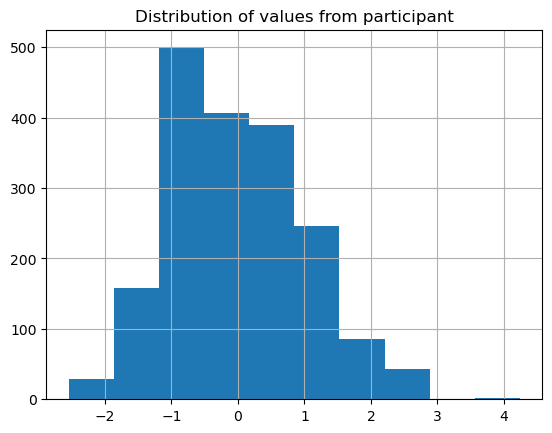

mean of the confidence distribution: -0.0042305689416798214
std of the confidence distribution: 1.0087323525592633


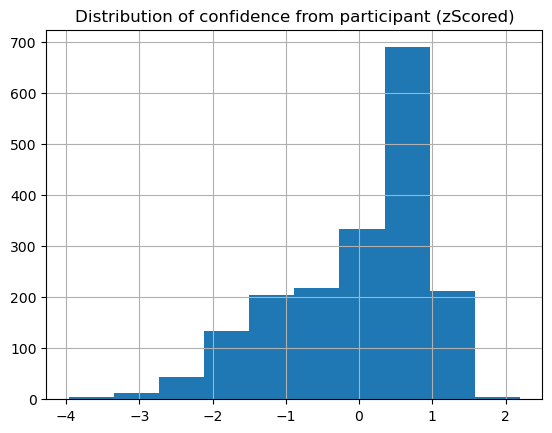

mean : 71.90215053763441
std  : 27.956900310032232


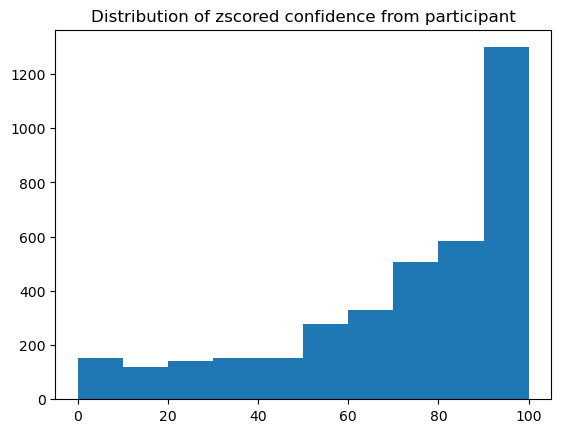

mean : 0.685640268068774
std  : 0.30555347501525715


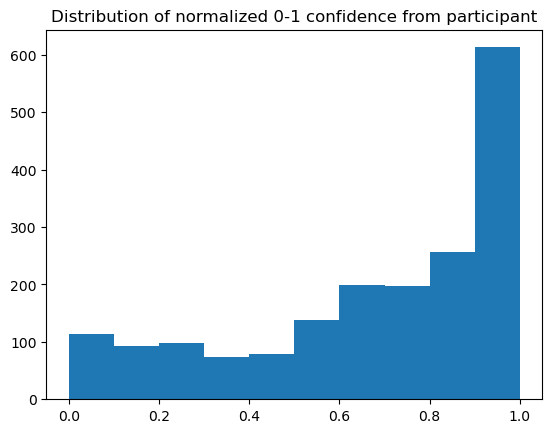

mean values -> high: 0.7043990584932006 ,  low:-0.8382157358374505
stdev values -> high: 0.7043990584932006 ,  low:0.4815617968617813
low values distribution: mean:-0.8382157358374505, var:0.4815617968617813
high values distribution: mean:0.8073312902665907, var:0.7043990584932006


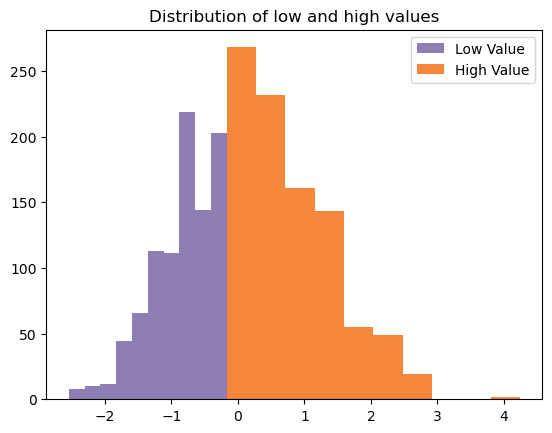

In [7]:
data_part_all0 =  data_all.loc[data_all.BlockCond == 2] # Dislike frame

val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test      = mainLoad(data_part_all0)

In [17]:
n_trials = len (val_a)
RANDOM_SEED = 58
rng = np.random.default_rng(RANDOM_SEED)

# Fixed means of the low (mu[0]) and high (mu[1]) evidence belief distributions
mu = [lvalParam[0],hvalParam[0]]
    
with pm.Model() as model_peb2:
    # Free parameters: SDs of the belief distributions (sigmaBel1: low-evidence, sigmaBel2: high-evidence category)
    sigmaGen1 = pm.Normal('sigmaBel1', mu=5, sigma=1) # low value distribution
    sigmaGen2 = pm.Normal('sigmaBel2', mu=5, sigma=1) # high value distribution
    
    # Observed (z-scored) evidence for the left/right option on each trial
    lVal = pm.Normal('lVal', mu = val_a, sigma = 0.001 , shape = n_trials)
    rVal = pm.Normal('rVal', mu = val_b, sigma = 0.001  , shape = n_trials)

    # Log-likelihood ratio that <right, left> = <high, low> rather than <low, high> evidence
    # (Gaussian belief distributions with means mu and SDs sigmaGen1/sigmaGen2)
    LLR = pm.Deterministic('LLR',  pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.)))) - 
                                    pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) + 
                                    pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) -
                                    pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.))))  )

    # Choice: logistic function of the LLR; beta scales its influence (prior precision tau = 0.001)
    beta = pm.Normal("beta", mu=0, tau=0.001, testval=0)
    p = pm.Deterministic("p", 1.0/(1. + pt.exp(beta*LLR) ))    
    
    choice = pm.Bernoulli("choice", p, observed=chosenByPart)

    # Confidence: logistic function of |LLR| and RT, weighted by betaConf and betaRT
    betaConf = pm.Normal("betaConf", mu=0, tau=0.001, testval=0)      
    betaRT = pm.Normal("betaRT", mu=0, tau=0.001, testval=0)
    
    conf = pm.Deterministic("conf",1.0/(1. + pt.exp(betaConf*pt.abs(LLR) + betaRT*rtByPart)) )

    # Reported confidence (normalised 0-1 per participant) with small noise (sigma = 0.025)
    confRep = pm.Normal('confReport',mu = conf, sigma=0.025, observed=confNormByPart)  

# MCMC settings: 4 chains x 4000 draws (NUTS), 1000 tuning steps
nsample = 4000
nchains = 4
    

In [18]:
with model_peb2:
    
    # Prior predictive samples, then posterior sampling with NUTS
    trace2 = pm.sample_prior_predictive( random_seed=rng)
    trace2.extend(pm.sample(nsample, cores=4,tune=1000, chains=nchains, return_inferencedata=True))

Sampling: [beta, betaConf, betaRT, choice, confReport, lVal, rVal, sigmaBel1, sigmaBel2]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigmaBel1, sigmaBel2, lVal, rVal, beta, betaConf, betaRT]


Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 3123 seconds.


In [23]:
# Save posterior (loaded by Figure_exp1-4_ModelFit_*.ipynb)
trace2.to_netcdf("sample_exp1_dislike_normalPrior.nc")

'sample_exp1_dislike_normalPrior.nc'

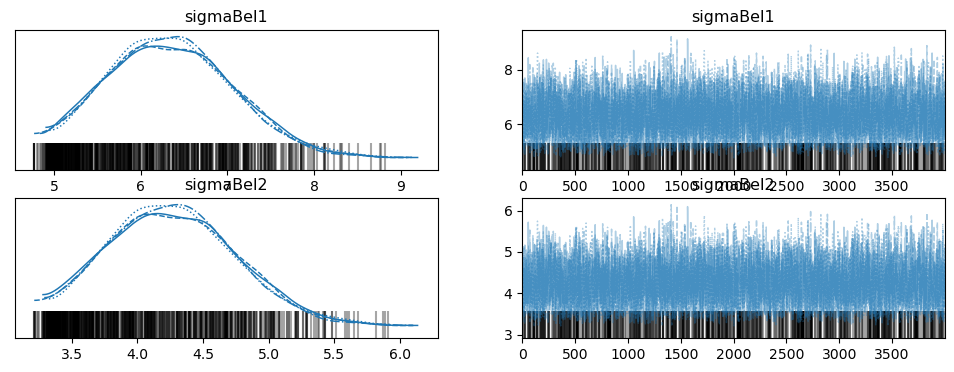

In [19]:
# Convergence check: trace plots
az.plot_trace(trace2, var_names=['sigmaBel1', 'sigmaBel2']);

In [20]:
# Convergence check: Gelman-Rubin R-hat
rhats_params = az.rhat(trace2, method="folded")
rhats_params

<xarray.Dataset>
Dimensions:     (lVal_dim_0: 1860, rVal_dim_0: 1860, LLR_dim_0: 1860,
                 p_dim_0: 1860, conf_dim_0: 1860)
Coordinates:
  * lVal_dim_0  (lVal_dim_0) int64 0 1 2 3 4 5 ... 1854 1855 1856 1857 1858 1859
  * rVal_dim_0  (rVal_dim_0) int64 0 1 2 3 4 5 ... 1854 1855 1856 1857 1858 1859
  * LLR_dim_0   (LLR_dim_0) int64 0 1 2 3 4 5 ... 1854 1855 1856 1857 1858 1859
  * p_dim_0     (p_dim_0) int64 0 1 2 3 4 5 6 ... 1854 1855 1856 1857 1858 1859
  * conf_dim_0  (conf_dim_0) int64 0 1 2 3 4 5 ... 1854 1855 1856 1857 1858 1859
Data variables:
    sigmaBel1   float64 1.001
    sigmaBel2   float64 1.001
    lVal        (lVal_dim_0) float64 1.001 1.0 1.0 1.001 ... 1.001 1.001 1.002
    rVal        (rVal_dim_0) float64 1.001 1.0 1.001 1.0 ... 1.001 0.9999 1.001
    beta        float64 1.0
    betaConf    float64 1.001
    betaRT      float64 1.0
    LLR         (LLR_dim_0) float64 1.001 1.001 1.001 ... 1.001 1.001 1.001
    p           (p_dim_0) float64 1.001 1.001 1.001 1.001 ... 1.0 1.0 1.0 1.001
    conf        (conf_dim_0) float64 1.0 0.9999 1.0 1.0 ... 1.0 1.0 0.9999 1.0

Compare: Mean1 = 6.345150737362154; Mean2 = 4.266877134424094; [mean1 - mean2] =  2.0782736029380597; t =  1112.14 ; p-value =0.0


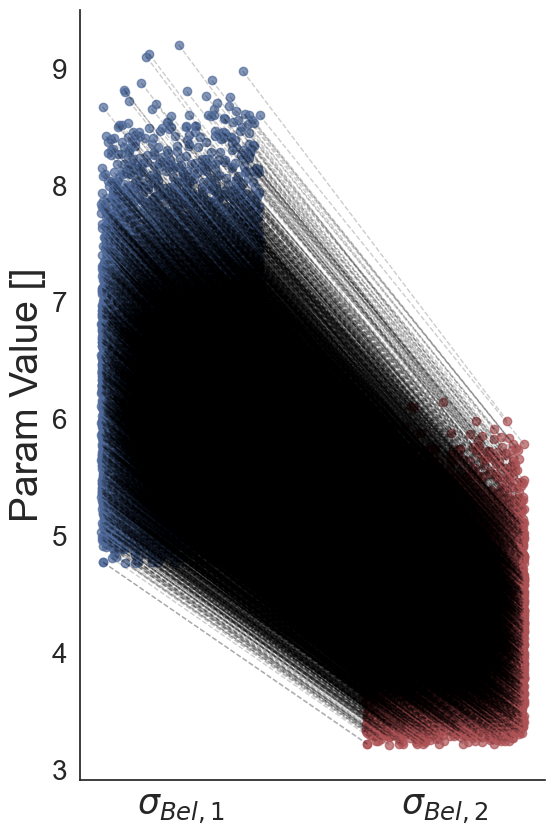

In [21]:
# Posterior of sigmaBel1 (low) vs sigmaBel2 (high)
fs.ttestsPlot(trace2.posterior['sigmaBel1'].values.flatten(), trace2.posterior['sigmaBel2'].values.flatten(),'#4F6A9A','#AC5255',"$\sigma_{Bel,1}$","$\sigma_{Bel,2}$",title = 'Param Value []')

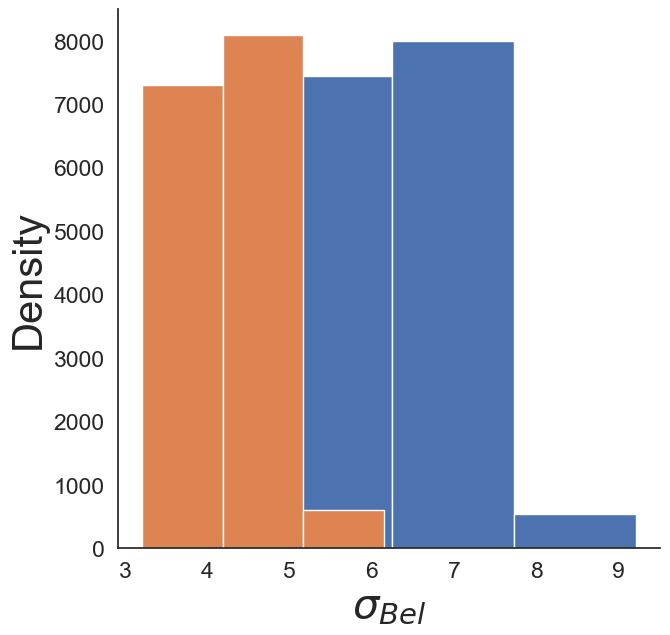

Proportion density above 0 : 0.0
Proportion density below 0 : 1.0
Mean sigmaBel1:6.345150737362154; SD sigmaBel1:0.7179908221356998
Mean sigmaBel2:4.266877134424094; SD sigmaBel2:0.48277342550832986
Delta sigmaBel mean:-2.0782736029380593; SD:0.23636918742281351


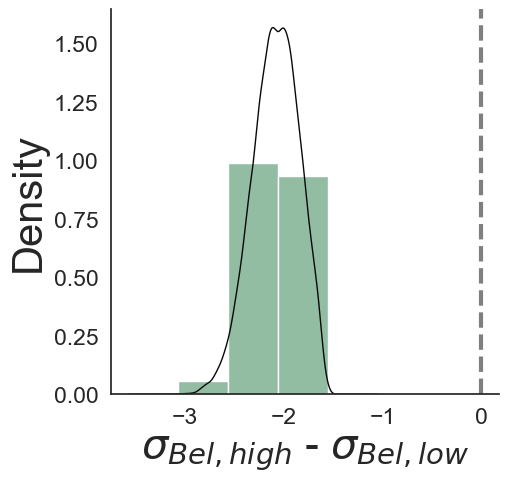

In [22]:
# Posterior of the belief-variance asymmetry (sigmaBel,high - sigmaBel,low)
fs.plotSigmaBelDensity(trace2, colorP = '#92BDA3',n_bins = 3,figName = 'figures/PEB_Model1RT_sigmaBelDensityLowMo.svg')

# Like frame

mean of the value distribution: -0.008254252744129761
std of the value distribution: 0.9944445184145924


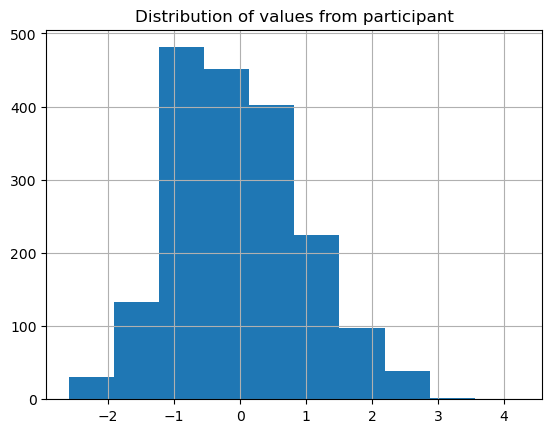

mean of the confidence distribution: -0.0037428708405745545
std of the confidence distribution: 1.0052979390969752


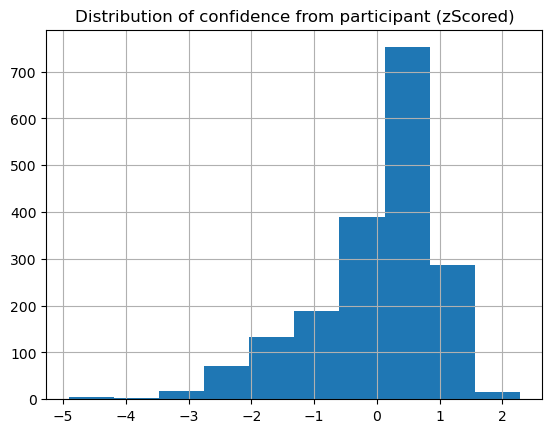

mean : 76.77258064516128
std  : 24.48782670596006


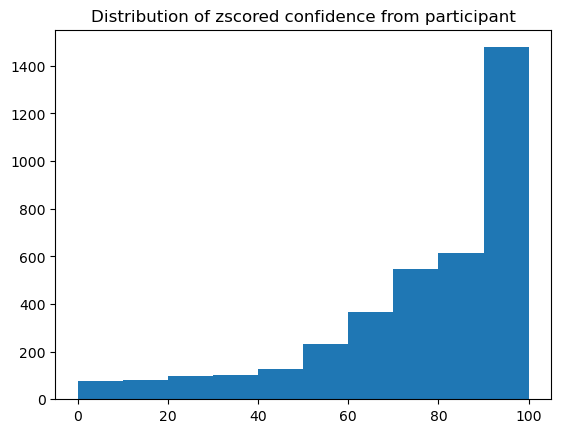

mean : 0.7265132834509263
std  : 0.2792316828970505


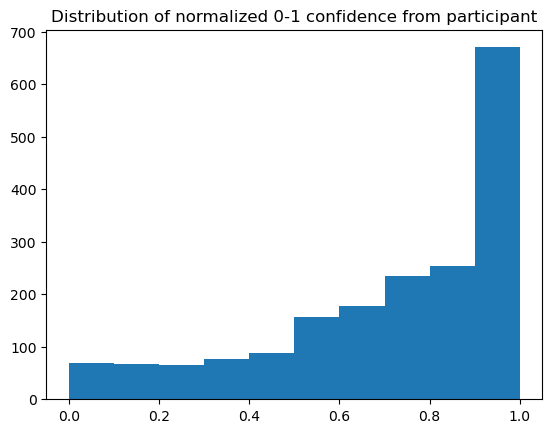

mean values -> high: 0.6788287640343346 ,  low:-0.8083217543745521
stdev values -> high: 0.6788287640343346 ,  low:0.4861710699343596
low values distribution: mean:-0.8083217543745521, var:0.4861710699343596
high values distribution: mean:0.7928236783310723, var:0.6788287640343346


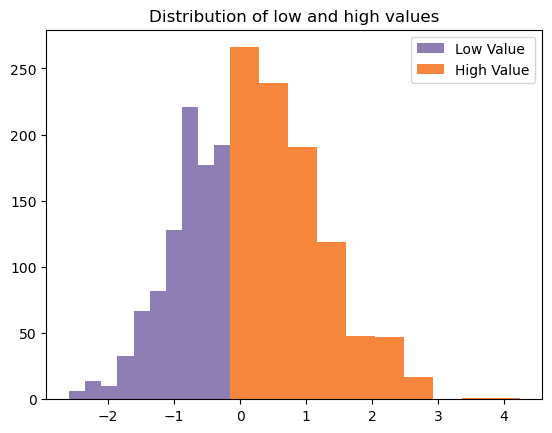

In [6]:
data_all = pd.read_csv('../Data/Sepulveda2020/DataFoodFramingNotebook_31.csv') 

data_part_all0 =  data_all.loc[data_all.BlockCond == 1] # Like frame

val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test      = mainLoad(data_part_all0)

In [7]:
n_trials = len (val_a)
RANDOM_SEED = 58
rng = np.random.default_rng(RANDOM_SEED)

# Fixed means of the low (mu[0]) and high (mu[1]) evidence belief distributions
mu = [lvalParam[0],hvalParam[0]]
    
with pm.Model() as model_peb2:
    # Free parameters: SDs of the belief distributions (sigmaBel1: low-evidence, sigmaBel2: high-evidence category)
    sigmaGen1 = pm.Normal('sigmaBel1', mu=5, sigma=1) # low value distribution
    sigmaGen2 = pm.Normal('sigmaBel2', mu=5, sigma=1) # high value distribution
    
    # Observed (z-scored) evidence for the left/right option on each trial
    lVal = pm.Normal('lVal', mu = val_a, sigma = 0.001 , shape = n_trials)
    rVal = pm.Normal('rVal', mu = val_b, sigma = 0.001  , shape = n_trials)

    # Log-likelihood ratio that <right, left> = <high, low> rather than <low, high> evidence
    # (Gaussian belief distributions with means mu and SDs sigmaGen1/sigmaGen2)
    LLR = pm.Deterministic('LLR',  pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.)))) - 
                                    pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) + 
                                    pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) -
                                    pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.))))  )

    # Choice: logistic function of the LLR; beta scales its influence (prior precision tau = 0.001)
    beta = pm.Normal("beta", mu=0, tau=0.001, testval=0)
    p = pm.Deterministic("p", 1.0/(1. + pt.exp(beta*LLR) ))    
    
    choice = pm.Bernoulli("choice", p, observed=chosenByPart)

    # Confidence: logistic function of |LLR| and RT, weighted by betaConf and betaRT
    betaConf = pm.Normal("betaConf", mu=0, tau=0.001, testval=0)      
    betaRT = pm.Normal("betaRT", mu=0, tau=0.001, testval=0)
    
    conf = pm.Deterministic("conf",1.0/(1. + pt.exp(betaConf*pt.abs(LLR) + betaRT*rtByPart)) )

    # Reported confidence (normalised 0-1 per participant) with small noise (sigma = 0.025)
    confRep = pm.Normal('confReport',mu = conf, sigma=0.025, observed=confNormByPart)  

# MCMC settings: 4 chains x 4000 draws (NUTS), 1000 tuning steps
nsample = 4000
nchains = 4
    
with model_peb2:
    
    # Prior predictive samples, then posterior sampling with NUTS
    trace2 = pm.sample_prior_predictive( random_seed=rng)
    trace2.extend(pm.sample(nsample, cores=4,tune=1000, chains=nchains, return_inferencedata=True))

Sampling: [beta, betaConf, betaRT, choice, confReport, lVal, rVal, sigmaBel1, sigmaBel2]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigmaBel1, sigmaBel2, lVal, rVal, beta, betaConf, betaRT]


Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 2041 seconds.


In [8]:
# Save posterior (loaded by Figure_exp1-4_ModelFit_*.ipynb)
trace2.to_netcdf("sample_exp1_like_normalPrior.nc")

'sample_exp1_like_normalPrior.nc'

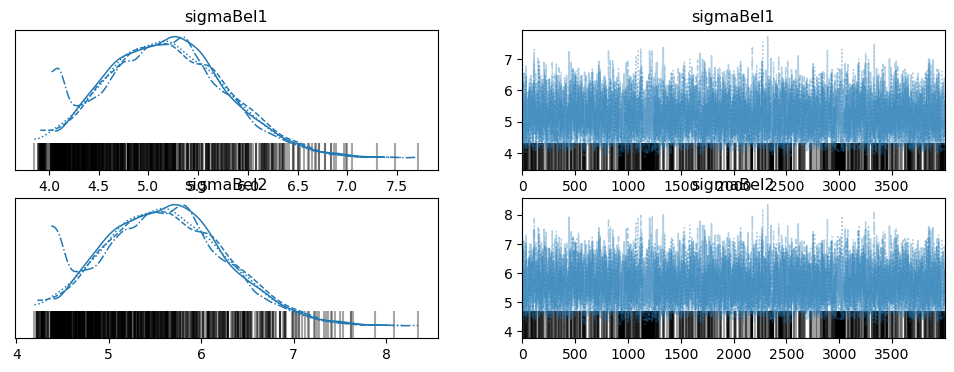

In [9]:
# Convergence check: trace plots
az.plot_trace(trace2, var_names=['sigmaBel1', 'sigmaBel2']);

In [10]:
# Convergence check: Gelman-Rubin R-hat
rhats_params = az.rhat(trace2, method="folded")
rhats_params

<xarray.Dataset>
Dimensions:     (lVal_dim_0: 1860, rVal_dim_0: 1860, LLR_dim_0: 1860,
                 p_dim_0: 1860, conf_dim_0: 1860)
Coordinates:
  * lVal_dim_0  (lVal_dim_0) int64 0 1 2 3 4 5 ... 1854 1855 1856 1857 1858 1859
  * rVal_dim_0  (rVal_dim_0) int64 0 1 2 3 4 5 ... 1854 1855 1856 1857 1858 1859
  * LLR_dim_0   (LLR_dim_0) int64 0 1 2 3 4 5 ... 1854 1855 1856 1857 1858 1859
  * p_dim_0     (p_dim_0) int64 0 1 2 3 4 5 6 ... 1854 1855 1856 1857 1858 1859
  * conf_dim_0  (conf_dim_0) int64 0 1 2 3 4 5 ... 1854 1855 1856 1857 1858 1859
Data variables:
    sigmaBel1   float64 1.0
    sigmaBel2   float64 1.0
    lVal        (lVal_dim_0) float64 1.0 1.0 1.002 1.001 ... 1.0 1.001 1.001
    rVal        (rVal_dim_0) float64 1.0 1.001 1.001 1.0 ... 1.001 1.001 1.0
    beta        float64 1.0
    betaConf    float64 1.0
    betaRT      float64 1.001
    LLR         (LLR_dim_0) float64 1.001 1.001 1.001 ... 1.001 1.001 1.001
    p           (p_dim_0) float64 1.001 1.001 1.0 1.0 1.0 ... 1.0 1.001 1.0 1.0
    conf        (conf_dim_0) float64 0.9999 1.001 1.0 1.0 ... 1.0 1.0 1.0 1.0

Compare: Mean1 = 5.176733996666735; Mean2 = 5.6117404956500305; [mean1 - mean2] =  -0.43500649898329513; t =  -940.79 ; p-value =0.0


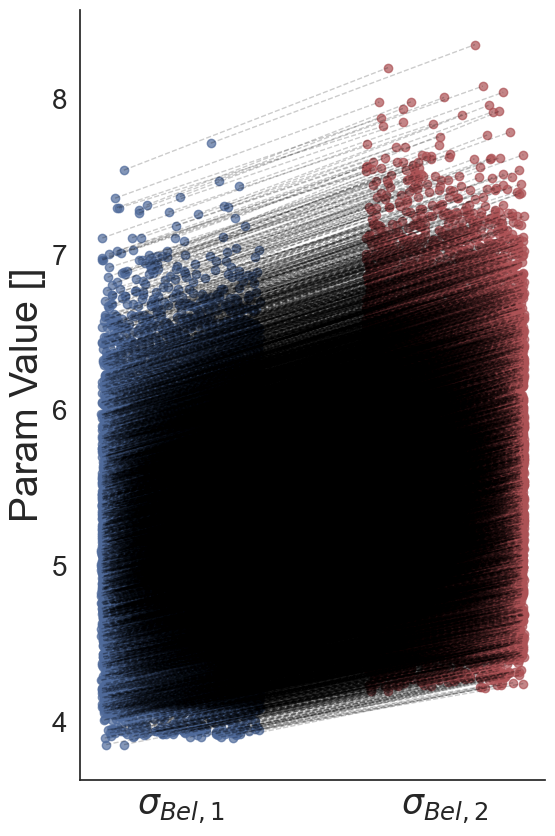

In [11]:
# Posterior of sigmaBel1 (low) vs sigmaBel2 (high)
fs.ttestsPlot(trace2.posterior['sigmaBel1'].values.flatten(), trace2.posterior['sigmaBel2'].values.flatten(),'#4F6A9A','#AC5255',"$\sigma_{Bel,1}$","$\sigma_{Bel,2}$",title = 'Param Value []')

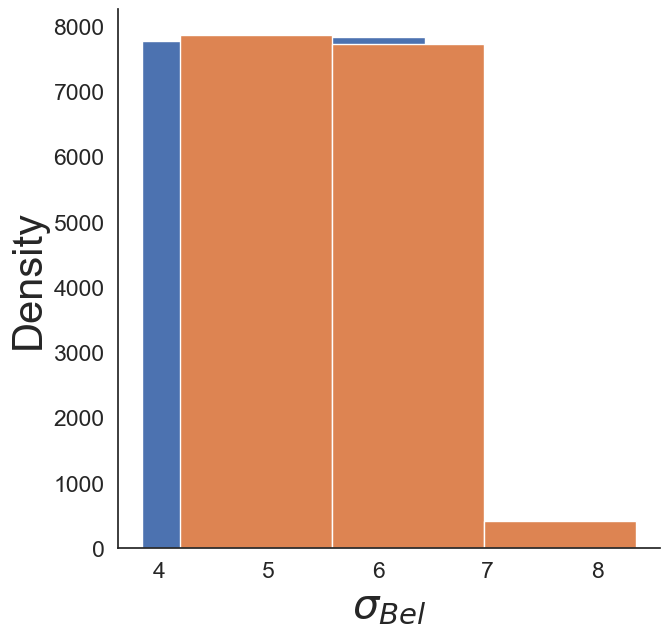

Proportion density above 0 : 1.0
Proportion density below 0 : 0.0
Mean sigmaBel1:5.176733996666735; SD sigmaBel1:0.6031168862293487
Mean sigmaBel2:5.6117404956500305; SD sigmaBel2:0.654030582403374
Delta sigmaBel mean:0.43500649898329563; SD:0.05848548719751412


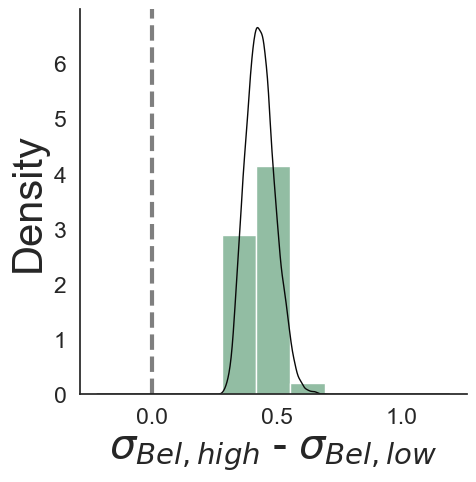

In [12]:
# Posterior of the belief-variance asymmetry (sigmaBel,high - sigmaBel,low)
fs.plotSigmaBelDensity(trace2, colorP = '#92BDA3',n_bins = 3,figName = 'figures/PEB_Model1RT_sigmaBelDensityLowMo.svg')